In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [18]:
data=pd.read_csv(r"placement.csv")   
data.shape

(200, 2)

In [19]:

X_train,X_test,y_train,y_test=train_test_split(data.drop(columns='package'),data['package'],test_size=0.2,random_state=42)

lr=LinearRegression()

lr.fit(X_train,y_train)
lr.coef_

array([0.57425647])

In [13]:
y_pred=lr.predict(X_test)
score=r2_score(y_test,y_pred)
score

0.7730984312051673

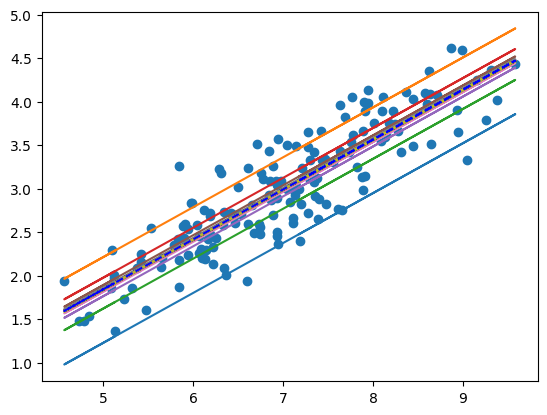

In [28]:
# lets M is fix and i want to find b

n=0.8
b=0
m=0.5742
epoch=100
plt.scatter(X_train,y_train)
plt.plot(X_train['cgpa'],lr.predict(X_train),color="red")
for i in range(epoch):
    step_size=(-2*np.mean(y_train-(m*X_train['cgpa'])-b))*n
    b = b-step_size
    y_pred= m*X_train['cgpa']+b
    if i==99:
        plt.plot(X_train,y_pred,color='blue',linestyle="--")
        break    
    plt.plot(X_train,y_pred)

In [61]:
n=0.01
b=0
m=8
for i in range(1000):
    b_new = b-(-2*np.mean(y_train-(m*X_train['cgpa'])-b))*n
    m = m-n*(-2*np.mean(X_train['cgpa']*(y_train-(m*X_train['cgpa'])-b)))
    b = b_new

b,m

(np.float64(-1.0322964245117765), np.float64(0.5749941204870473))

In [53]:
lr.intercept_,lr.coef_

(np.float64(-1.0270069374542108), array([0.57425647]))